In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.6f}".format)

# Load full sentiment dataset from NB3
sentiment = pd.read_csv(
    "../data/processed/sentiment_full.csv",
    parse_dates=["date"]
)

# Verify record count
print(f"Sentiment records loaded: {len(sentiment)}")
assert len(sentiment) == 95, \
    f"Expected 95, got {len(sentiment)}. " \
    f"Re-run NB3 Cell 6 with deduplication fix."

tickers = sentiment["ticker"].unique().tolist()

TICKER_COLORS = {
    "AAPL": "#378ADD",
    "MSFT": "#1D9E75",
    "TSLA": "#D85A30",
    "JPM":  "#7F77DD",
    "NVDA": "#BA7517"
}

print("=" * 55)
print("   NB4 — RETURN ANALYSIS")
print("=" * 55)
print(f"  Sentiment records:  {len(sentiment)}")
print(f"  Companies:          {tickers}")
print(f"  Date range:         "
      f"{sentiment['date'].min().date()} to "
      f"{sentiment['date'].max().date()}")
print("=" * 55)

Sentiment records loaded: 95
   NB4 — RETURN ANALYSIS
  Sentiment records:  95
  Companies:          ['AAPL', 'JPM', 'MSFT', 'NVDA', 'TSLA']
  Date range:         2020-04-01 to 2024-10-01


In [2]:
# ============================================
# ROBUST PRICE DOWNLOAD
# Handles all yfinance MultiIndex formats
# ============================================

all_tickers = tickers + ["SPY"]
print(f"Downloading prices for: {all_tickers}")

# Download with explicit date range
prices_raw = yf.download(
    all_tickers,
    start="2019-01-01",
    end="2025-06-30",
    auto_adjust=True,
    progress=True
)

print(f"\nRaw download shape:   {prices_raw.shape}")
print(f"Raw columns type:     {type(prices_raw.columns)}")
print(f"Raw columns:\n{prices_raw.columns.tolist()[:10]}")

# ============================================
# HANDLE MULTIINDEX COLUMNS
# yfinance returns MultiIndex when multiple
# tickers are downloaded
# ============================================
if isinstance(prices_raw.columns, pd.MultiIndex):
    print("\nMultiIndex detected — extracting Close")

    # Try "Close" first then "Adj Close"
    if "Close" in prices_raw.columns.get_level_values(0):
        prices = prices_raw["Close"].copy()
    elif "Adj Close" in prices_raw.columns.get_level_values(0):
        prices = prices_raw["Adj Close"].copy()
    else:
        # Take first level
        first_field = prices_raw.columns.get_level_values(0)[0]
        prices = prices_raw[first_field].copy()
        print(f"Using field: {first_field}")

else:
    print("\nSingle-level columns detected")
    # Single ticker or already flat
    if "Close" in prices_raw.columns:
        prices = prices_raw[["Close"]].copy()
        prices.columns = ["AAPL"]
    else:
        prices = prices_raw.copy()

# Clean column names
prices.columns = [
    str(c).strip().replace(" ", "_")
    for c in prices.columns
]

print(f"\nPrices shape:   {prices.shape}")
print(f"Prices columns: {prices.columns.tolist()}")
print(f"Missing values: {prices.isnull().sum().sum()}")

# ============================================
# VERIFY ALL TICKERS PRESENT
# ============================================
missing_tickers = [
    t for t in all_tickers
    if t not in prices.columns
]

if missing_tickers:
    print(f"\nMissing tickers: {missing_tickers}")
    print("Downloading missing tickers individually...")

    for t in missing_tickers:
        try:
            single = yf.download(
                t,
                start="2019-01-01",
                end="2025-06-30",
                auto_adjust=True,
                progress=False
            )
            if isinstance(single.columns,
                          pd.MultiIndex):
                col = single["Close"]
            elif "Close" in single.columns:
                col = single["Close"]
            else:
                col = single.iloc[:, 0]

            prices[t] = col
            print(f"  {t}: downloaded "
                  f"{len(col)} rows")
        except Exception as e:
            print(f"  {t}: failed — {e}")

# ============================================
# FIND MARKET BENCHMARK COLUMN
# ============================================
market_col = None
for candidate in ["SPY", "^GSPC",
                  "spy", "GSPC"]:
    if candidate in prices.columns:
        market_col = candidate
        break

if market_col is None:
    print("\nSPY not found — downloading separately")
    try:
        spy = yf.download(
            "SPY",
            start="2019-01-01",
            end="2025-06-30",
            auto_adjust=True,
            progress=False
        )
        if isinstance(spy.columns, pd.MultiIndex):
            prices["SPY"] = spy["Close"]["SPY"]
        else:
            prices["SPY"] = spy["Close"]
        market_col = "SPY"
        print("SPY downloaded successfully")
    except Exception as e:
        print(f"SPY download failed: {e}")
        # Use first available ticker as proxy
        market_col = prices.columns[0]
        print(f"Using {market_col} as proxy")

# ============================================
# DROP ROWS WITH ALL NaN AND CALCULATE RETURNS
# ============================================
prices  = prices.dropna(how="all")
returns = prices.pct_change().dropna(how="all")

# Final verification
print("\n" + "=" * 55)
print("   PRICE DOWNLOAD COMPLETE")
print("=" * 55)
print(f"  Prices shape:    {prices.shape}")
print(f"  Returns shape:   {returns.shape}")

if len(returns) > 0:
    print(f"  Date range:      "
          f"{returns.index[0].date()} to "
          f"{returns.index[-1].date()}")
else:
    print("  ERROR: Returns DataFrame is empty!")

print(f"  Market column:   {market_col}")
print(f"  Tickers found:   "
      f"{[t for t in tickers if t in returns.columns]}")
print(f"  Tickers missing: "
      f"{[t for t in tickers if t not in returns.columns]}")
print("=" * 55)

[*********************100%***********************]  6 of 6 completed


Raw download shape:   (1631, 30)
Raw columns type:     <class 'pandas.MultiIndex'>
Raw columns:
[('Close', 'AAPL'), ('Close', 'JPM'), ('Close', 'MSFT'), ('Close', 'NVDA'), ('Close', 'SPY'), ('Close', 'TSLA'), ('High', 'AAPL'), ('High', 'JPM'), ('High', 'MSFT'), ('High', 'NVDA')]

MultiIndex detected — extracting Close

Prices shape:   (1631, 6)
Prices columns: ['AAPL', 'JPM', 'MSFT', 'NVDA', 'SPY', 'TSLA']
Missing values: 0

   PRICE DOWNLOAD COMPLETE
  Prices shape:    (1631, 6)
  Returns shape:   (1630, 6)
  Date range:      2019-01-03 to 2025-06-27
  Market column:   SPY
  Tickers found:   ['AAPL', 'JPM', 'MSFT', 'NVDA', 'TSLA']
  Tickers missing: []


In [3]:
# ============================================
# ABNORMAL RETURN CALCULATION
# Method: Market Model (CAPM)
#
# For each earnings date:
# 1. Estimate beta using 60-day pre-event window
# 2. Calculate expected return = alpha + beta * Rm
# 3. Abnormal return = actual - expected
# 4. CAR(0,+2) = sum of days 0, +1, +2
#
# This is the standard academic event study
# methodology (Brown and Warner 1985)
# ============================================

def find_nearest_trading_day(
        target_date: pd.Timestamp,
        trading_dates: pd.DatetimeIndex,
        direction: str = "forward",
        max_days: int = 5) -> pd.Timestamp:
    """
    Find nearest trading day to target date.
    direction: 'forward' or 'backward'
    Handles weekends and market holidays.
    """
    for i in range(max_days + 1):
        if direction == "forward":
            candidate = target_date + \
                        pd.Timedelta(days=i)
        else:
            candidate = target_date - \
                        pd.Timedelta(days=i)

        if candidate in trading_dates:
            return candidate

    return None


def calc_car(
        ticker: str,
        event_date: pd.Timestamp,
        returns_df: pd.DataFrame,
        market_col: str,
        est_window: int = 60,
        event_window: int = 3) -> dict:
    """
    Calculate Cumulative Abnormal Return
    around an earnings event date.

    est_window:   days before event for beta estimation
    event_window: days after event for CAR (inclusive of day 0)
    """
    if ticker not in returns_df.columns:
        return {}
    if market_col not in returns_df.columns:
        return {}

    trading_dates = returns_df.index

    # Find nearest trading day
    event_td = find_nearest_trading_day(
        event_date, trading_dates, "forward")
    if event_td is None:
        return {}

    event_idx = trading_dates.get_loc(event_td)

    # Need sufficient history
    if event_idx < est_window + 5:
        return {}

    # Estimation window — 60 days before event
    est_start = event_idx - est_window
    est_end   = event_idx

    y_est = returns_df[ticker].iloc[
        est_start:est_end].dropna()
    X_est = returns_df[market_col].iloc[
        est_start:est_end].loc[y_est.index]

    if len(y_est) < 20:
        return {}

    # OLS market model
    X_ols  = sm.add_constant(X_est)
    model  = sm.OLS(y_est, X_ols).fit()
    alpha  = model.params.iloc[0]
    beta   = model.params.iloc[1]
    r2_est = model.rsquared

    # Event window returns
    abnormal_returns = []
    for day_offset in range(event_window):
        idx = event_idx + day_offset
        if idx >= len(trading_dates):
            break

        actual   = returns_df[ticker].iloc[idx]
        mkt      = returns_df[market_col].iloc[idx]
        expected = alpha + beta * mkt
        abnormal = actual - expected

        abnormal_returns.append({
            "day":           day_offset,
            "actual_ret":    actual,
            "expected_ret":  expected,
            "abnormal_ret":  abnormal,
            "market_ret":    mkt,
        })

    if not abnormal_returns:
        return {}

    ar_df = pd.DataFrame(abnormal_returns)
    car   = ar_df["abnormal_ret"].sum()
    ar0   = float(
        ar_df[ar_df["day"]==0]["abnormal_ret"]
        .values[0])

    # Pre-event return (momentum control)
    pre_start = max(0, event_idx - 20)
    pre_ret   = returns_df[ticker].iloc[
        pre_start:event_idx].mean() * 252

    return {
        "car_3day":      round(car, 6),
        "ar_day0":       round(ar0, 6),
        "beta_est":      round(beta, 4),
        "alpha_est":     round(alpha, 6),
        "r2_market_model": round(r2_est, 4),
        "n_est_days":    len(y_est),
        "event_date":    event_td,
        "pre_event_ret": round(pre_ret, 4),
    }


# Calculate CARs for all sentiment events
print("Calculating abnormal returns...")
print("Method: Market model CAR(0,+2)")
print()

car_records = []
skipped     = 0

for _, row in sentiment.iterrows():
    result = calc_car(
        ticker     = row["ticker"],
        event_date = row["date"],
        returns_df = returns,
        market_col = market_col,
        est_window = 60,
        event_window = 3
    )

    if not result:
        skipped += 1
        continue

    record = {
        "ticker":          row["ticker"],
        "date":            row["date"],
        "quarter":         row["quarter"],
        "tone":            row["tone"],
        "finbert_score":   row["finbert_score"],
        "vader_compound":  row["vader_compound"],
        "composite_score": row["composite_score"],
        "finbert_score_change":
            row.get("finbert_score_change", np.nan),
        "vader_compound_change":
            row.get("vader_compound_change", np.nan),
        "composite_change":
            row.get("composite_change", np.nan),
        "uncertain_ratio": row.get(
            "uncertain_ratio", np.nan),
        "positive_ratio":  row.get(
            "positive_ratio", np.nan),
        "forward_count":   row.get(
            "forward_count", np.nan),
        "net_tone_ratio":  row.get(
            "net_tone_ratio", np.nan),
    }
    record.update(result)
    car_records.append(record)

analysis_df = pd.DataFrame(car_records)
analysis_df["date"] = pd.to_datetime(
    analysis_df["date"])

print(f"Events processed:  {len(analysis_df)}")
print(f"Events skipped:    {skipped}")
print(f"\nCAR summary:")
print(analysis_df.groupby("ticker")[
    "car_3day"
].agg(["mean","std","min","max"]).round(4)
 .to_string())

Calculating abnormal returns...
Method: Market model CAR(0,+2)

Events processed:  95
Events skipped:    0

CAR summary:
            mean      std       min      max
ticker                                      
AAPL   -0.005900 0.020900 -0.045800 0.026400
JPM     0.005800 0.021200 -0.019900 0.057700
MSFT   -0.003700 0.024100 -0.059800 0.024500
NVDA   -0.014000 0.025000 -0.051000 0.052700
TSLA    0.000900 0.094100 -0.187800 0.203500


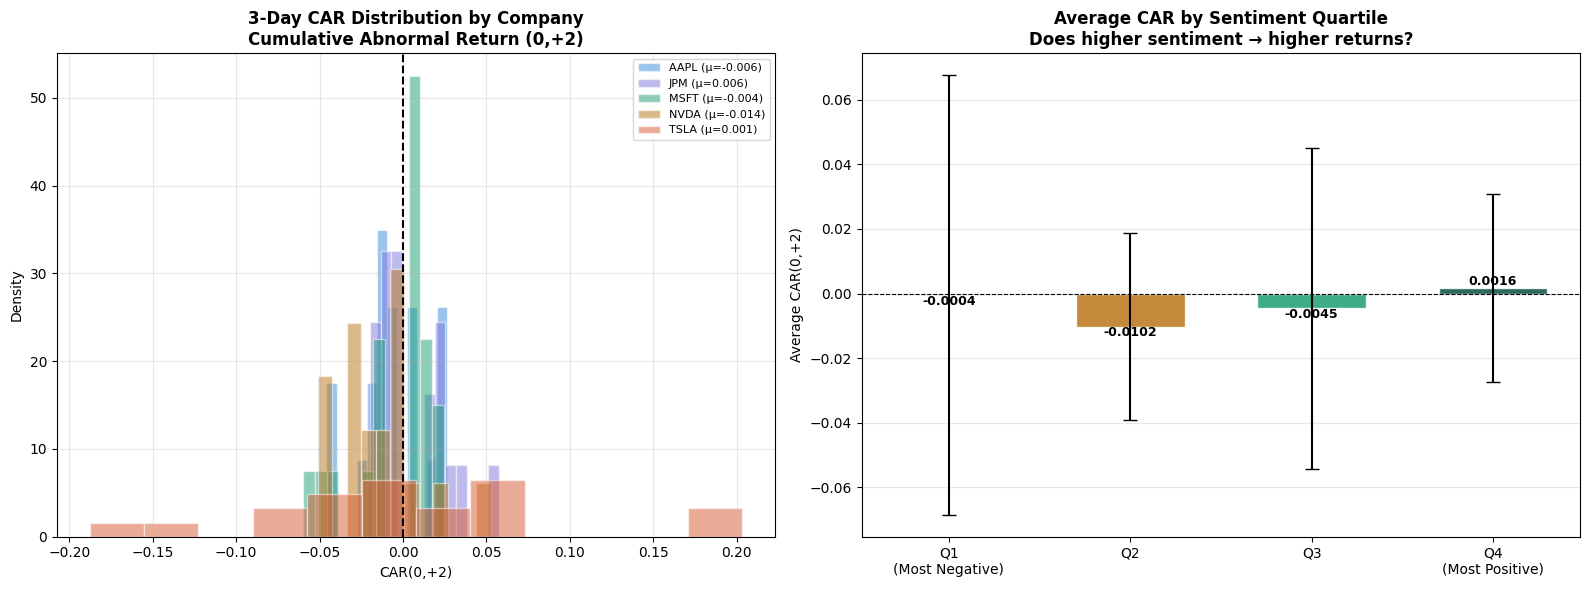

Event study chart saved


In [4]:
# ============================================
# EVENT STUDY CHART
# Average abnormal returns around earnings
# ============================================
fig, axes = plt.subplots(
    1, 2, figsize=(16, 6))

# Chart 1 — CAR distribution by company
ax1 = axes[0]
for ticker in tickers:
    sub = analysis_df[
        analysis_df["ticker"]==ticker][
        "car_3day"].dropna()
    if len(sub) == 0:
        continue
    color = TICKER_COLORS.get(ticker, "grey")
    ax1.hist(
        sub, bins=12,
        alpha=0.5, color=color,
        label=f"{ticker} "
              f"(μ={sub.mean():.3f})",
        density=True, edgecolor="white")

ax1.axvline(0, color="black",
            linewidth=1.5, linestyle="--")
ax1.set_title(
    "3-Day CAR Distribution by Company\n"
    "Cumulative Abnormal Return (0,+2)",
    fontweight="bold", fontsize=12)
ax1.set_xlabel("CAR(0,+2)")
ax1.set_ylabel("Density")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Chart 2 — CAR by sentiment quartile
ax2 = axes[1]
temp = analysis_df.dropna(
    subset=["finbert_score","car_3day"])
if len(temp) > 0:
    temp["sentiment_quartile"] = pd.qcut(
        temp["finbert_score"],
        q=4,
        labels=["Q1\n(Most Negative)",
                "Q2", "Q3",
                "Q4\n(Most Positive)"],
        duplicates="drop"
    )
    quartile_means = temp.groupby(
        "sentiment_quartile",
        observed=True)["car_3day"].mean()
    quartile_std   = temp.groupby(
        "sentiment_quartile",
        observed=True)["car_3day"].std()

    colors_q = ["#D85A30","#BA7517",
                "#1D9E75","#085041"]
    bars = ax2.bar(
        quartile_means.index,
        quartile_means.values,
        color=colors_q[:len(quartile_means)],
        alpha=0.85, edgecolor="white",
        width=0.6)
    ax2.errorbar(
        range(len(quartile_means)),
        quartile_means.values,
        yerr=quartile_std.values,
        fmt="none", color="black",
        capsize=5, linewidth=1.5)
    ax2.axhline(
        0, color="black",
        linewidth=0.8, linestyle="--")
    ax2.set_title(
        "Average CAR by Sentiment Quartile\n"
        "Does higher sentiment → higher returns?",
        fontweight="bold", fontsize=12)
    ax2.set_ylabel("Average CAR(0,+2)")
    ax2.grid(alpha=0.3, axis="y")

    for bar, val in zip(
            bars, quartile_means.values):
        ax2.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() +
            (0.001 if val >= 0 else -0.003),
            f"{val:.4f}",
            ha="center", fontsize=9,
            fontweight="bold")

plt.tight_layout()
plt.savefig(
    "../reports/figures/event_study.png",
    dpi=150, bbox_inches="tight")
plt.show()
print("Event study chart saved")

In [5]:
# ============================================
# SENTIMENT-RETURN REGRESSIONS
# Tests whether sentiment predicts CAR
# Uses HC3 robust standard errors
# ============================================

# Drop rows missing key variables
reg_df = analysis_df.dropna(
    subset=["car_3day","finbert_score",
            "vader_compound","composite_score"]
).copy()

print(f"Regression sample: {len(reg_df)} events")
y = reg_df["car_3day"]

# ============================================
# REGRESSION 1 — VADER compound → CAR
# ============================================
X1    = sm.add_constant(reg_df["vader_compound"])
reg1  = sm.OLS(y, X1).fit(cov_type="HC3")

# ============================================
# REGRESSION 2 — FinBERT score → CAR
# ============================================
X2    = sm.add_constant(reg_df["finbert_score"])
reg2  = sm.OLS(y, X2).fit(cov_type="HC3")

# ============================================
# REGRESSION 3 — Composite score → CAR
# ============================================
X3    = sm.add_constant(reg_df["composite_score"])
reg3  = sm.OLS(y, X3).fit(cov_type="HC3")

# ============================================
# REGRESSION 4 — Sentiment CHANGE → CAR
# Change more predictive than level
# ============================================
reg_change = reg_df.dropna(
    subset=["finbert_score_change"])
y4    = reg_change["car_3day"]
X4    = sm.add_constant(
    reg_change["finbert_score_change"])
reg4  = sm.OLS(y4, X4).fit(cov_type="HC3")

# ============================================
# REGRESSION 5 — Full model with controls
# ============================================
full_cols = [
    "finbert_score",
    "finbert_score_change",
    "uncertain_ratio",
    "forward_count",
    "pre_event_ret",  # Momentum control
]
available_cols = [
    c for c in full_cols
    if c in reg_df.columns and
    reg_df[c].notna().sum() > 10
]
reg_full_df = reg_df.dropna(
    subset=available_cols + ["car_3day"])
y5   = reg_full_df["car_3day"]
X5   = sm.add_constant(
    reg_full_df[available_cols])
reg5 = sm.OLS(y5, X5).fit(cov_type="HC3")

# ============================================
# RESULTS TABLE
# ============================================
print("=" * 70)
print("   SENTIMENT-RETURN REGRESSION RESULTS")
print("   Dependent variable: CAR(0,+2)")
print("   Standard errors: HC3 robust")
print("=" * 70)

regressions = [
    ("VADER → CAR",            reg1,
     "vader_compound"),
    ("FinBERT → CAR",          reg2,
     "finbert_score"),
    ("Composite → CAR",        reg3,
     "composite_score"),
    ("Sentiment Change → CAR", reg4,
     "finbert_score_change"),
]

print(f"\n  {'Model':<28} {'Coef':>9} "
      f"{'t-stat':>8} {'p-val':>8} "
      f"{'R²':>7} {'Sig':>5}")
print(f"  {'-'*67}")

for label, reg, var in regressions:
    if var not in reg.params.index:
        continue
    coef = reg.params[var]
    tval = reg.tvalues[var]
    pval = reg.pvalues[var]
    r2   = reg.rsquared
    sig  = ("***" if pval < 0.01 else
            "**"  if pval < 0.05 else
            "*"   if pval < 0.10 else "ns")
    print(f"  {label:<28} {coef:>9.5f} "
          f"{tval:>8.3f} {pval:>8.4f} "
          f"{r2:>7.4f} {sig:>5}")

print(f"\n  Full model ({len(available_cols)} vars):")
for var in available_cols:
    if var not in reg5.params.index:
        continue
    coef = reg5.params[var]
    tval = reg5.tvalues[var]
    pval = reg5.pvalues[var]
    sig  = ("***" if pval < 0.01 else
            "**"  if pval < 0.05 else
            "*"   if pval < 0.10 else "ns")
    print(f"    {var:<28} {coef:>9.5f} "
          f"{tval:>8.3f} {pval:>8.4f} {sig:>5}")
print(f"  Full model R²: {reg5.rsquared:.4f}")
print("=" * 70)

# Bonferroni correction note
print(f"\n  Multiple testing (Bonferroni):")
print(f"  Adjusted significance threshold: "
      f"{0.05/4:.4f}")
print(f"  (4 main regressions tested)")

Regression sample: 95 events
   SENTIMENT-RETURN REGRESSION RESULTS
   Dependent variable: CAR(0,+2)
   Standard errors: HC3 robust

  Model                             Coef   t-stat    p-val      R²   Sig
  -------------------------------------------------------------------
  VADER → CAR                    0.02140    0.950   0.3422  0.0208    ns
  FinBERT → CAR                 -0.01241   -0.657   0.5112  0.0172    ns
  Composite → CAR               -0.00915   -0.357   0.7210  0.0041    ns
  Sentiment Change → CAR        -0.00651   -0.626   0.5312  0.0098    ns

  Full model (4 vars):
    finbert_score                 -0.01028   -0.539   0.5898    ns
    finbert_score_change          -0.00234   -0.296   0.7673    ns
    uncertain_ratio               -0.22060   -1.067   0.2858    ns
    pre_event_ret                  0.00784    1.910   0.0561     *
  Full model R²: 0.0709

  Multiple testing (Bonferroni):
  Adjusted significance threshold: 0.0125
  (4 main regressions tested)


In [6]:
# ============================================
# PER-COMPANY REGRESSION
# The relationship likely differs by company
# TSLA should show strongest relationship
# ============================================
print("=" * 65)
print("   SENTIMENT-RETURN BY COMPANY")
print("=" * 65)

company_reg_rows = []
for ticker in tickers:
    sub = reg_df[
        reg_df["ticker"]==ticker].dropna(
        subset=["car_3day","finbert_score"])

    if len(sub) < 8:
        print(f"  {ticker}: insufficient data "
              f"({len(sub)} events)")
        continue

    y_c = sub["car_3day"]
    X_c = sm.add_constant(sub["finbert_score"])
    reg_c = sm.OLS(y_c, X_c).fit(
        cov_type="HC3")

    coef = reg_c.params.get(
        "finbert_score", np.nan)
    tval = reg_c.tvalues.get(
        "finbert_score", np.nan)
    pval = reg_c.pvalues.get(
        "finbert_score", np.nan)
    r2   = reg_c.rsquared

    sig  = ("***" if pval < 0.01 else
            "**"  if pval < 0.05 else
            "*"   if pval < 0.10 else "ns")

    # Spearman rank correlation
    spear, spear_p = spearmanr(
        sub["finbert_score"],
        sub["car_3day"])

    print(f"\n  {ticker}")
    print(f"  n events:    {len(sub)}")
    print(f"  OLS coef:    {coef:.5f} "
          f"t={tval:.2f} p={pval:.4f} {sig}")
    print(f"  R²:          {r2:.4f}")
    print(f"  Spearman r:  {spear:.4f} "
          f"p={spear_p:.4f}")

    company_reg_rows.append({
        "Ticker":      ticker,
        "N_events":    len(sub),
        "OLS_coef":    round(coef, 5),
        "t_stat":      round(tval, 3),
        "p_value":     round(pval, 4),
        "Significant": sig,
        "R2":          round(r2, 4),
        "Spearman_r":  round(spear, 4),
    })

company_reg_df = pd.DataFrame(
    company_reg_rows).set_index("Ticker")
print("\n" + "=" * 65)
print(company_reg_df.to_string())
company_reg_df.to_csv(
    "../data/results/company_regressions.csv")

   SENTIMENT-RETURN BY COMPANY

  AAPL
  n events:    19
  OLS coef:    0.01432 t=1.46 p=0.1449 ns
  R²:          0.0259
  Spearman r:  0.2119 p=0.3839

  JPM
  n events:    19
  OLS coef:    0.03371 t=1.55 p=0.1212 ns
  R²:          0.1210
  Spearman r:  0.4420 p=0.0581

  MSFT
  n events:    19
  OLS coef:    -0.01649 t=-2.92 p=0.0035 ***
  R²:          0.1869
  Spearman r:  -0.5338 p=0.0186

  NVDA
  n events:    19
  OLS coef:    -0.09019 t=-0.92 p=0.3570 ns
  R²:          0.0483
  Spearman r:  -0.0061 p=0.9801

  TSLA
  n events:    19
  OLS coef:    -0.01455 t=-0.38 p=0.7067 ns
  R²:          0.0140
  Spearman r:  -0.1386 p=0.5715

        N_events  OLS_coef    t_stat  p_value Significant       R2  Spearman_r
Ticker                                                                        
AAPL          19  0.014320  1.458000 0.144900          ns 0.025900    0.211900
JPM           19  0.033710  1.550000 0.121200          ns 0.121000    0.442000
MSFT          19 -0.016490 -2.916000 0

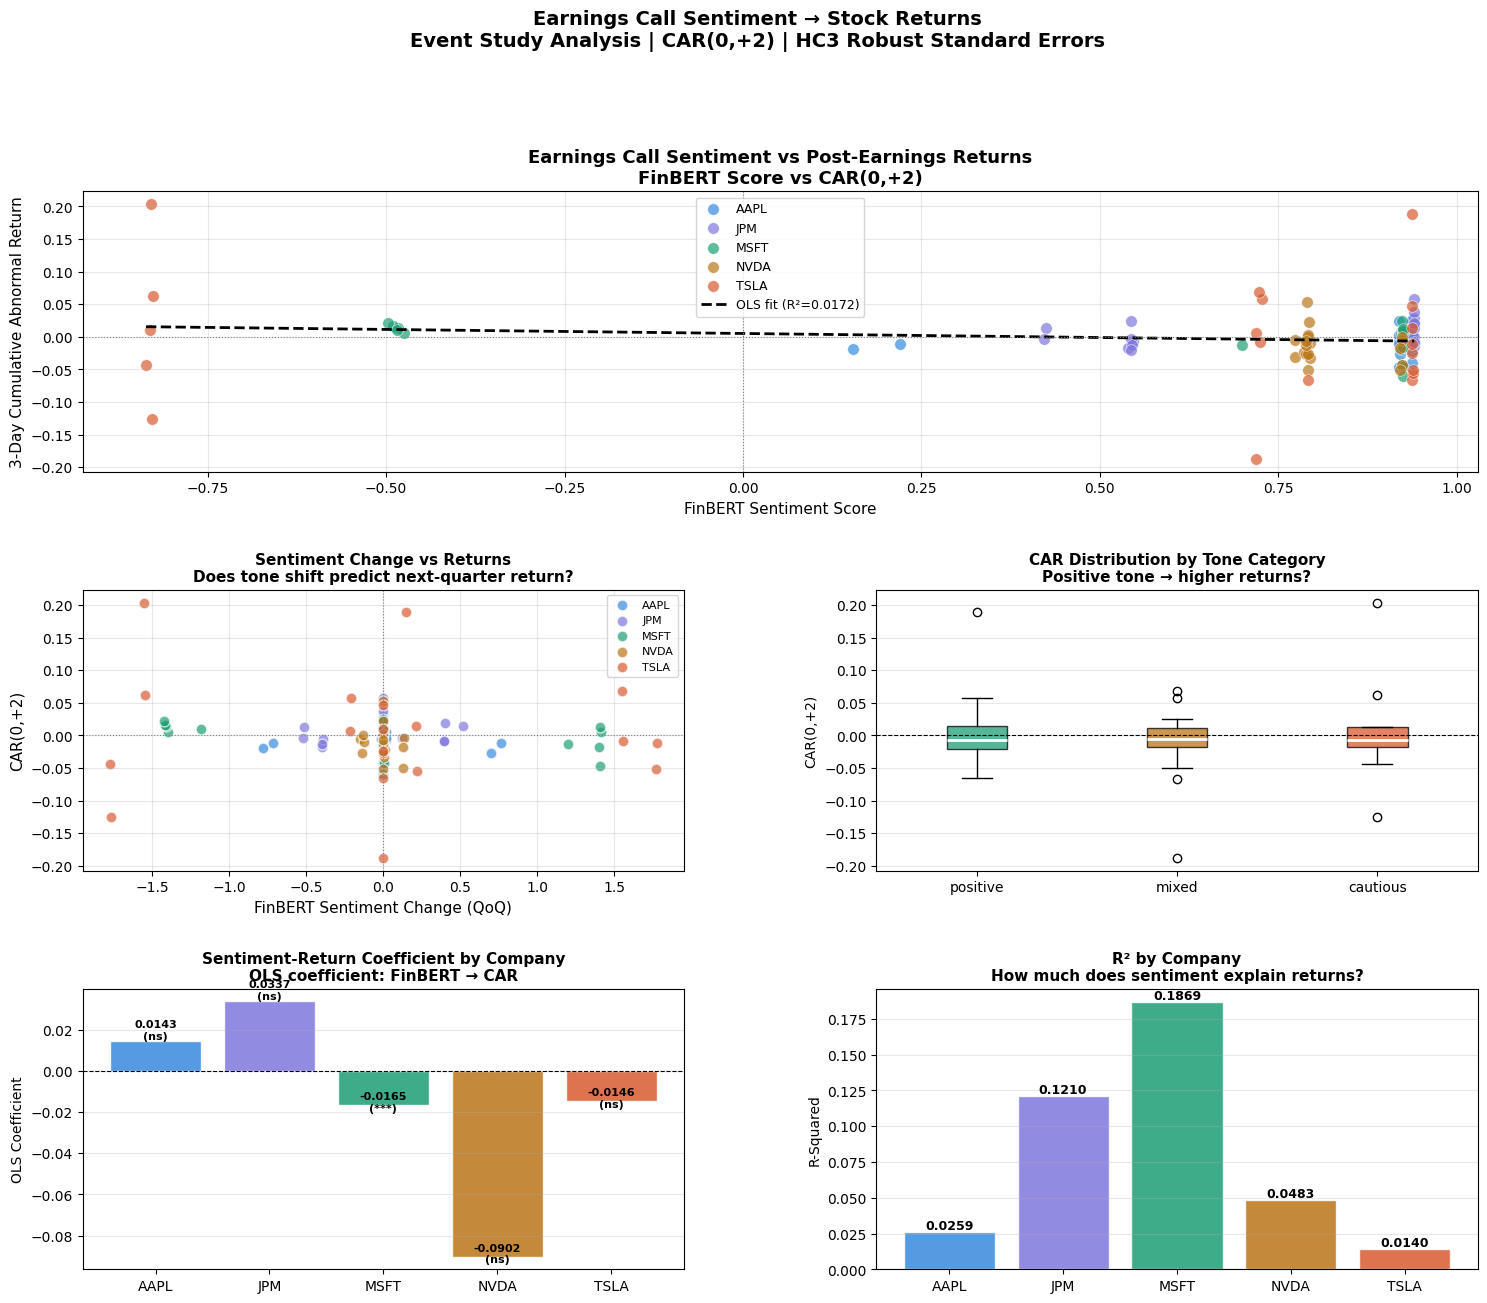

Sentiment-returns chart saved


In [7]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(
    3, 2, figure=fig,
    hspace=0.42, wspace=0.32)

# Chart 1 — FinBERT vs CAR scatter
ax1 = fig.add_subplot(gs[0, :])
for ticker in tickers:
    sub = reg_df[
        reg_df["ticker"]==ticker]
    color = TICKER_COLORS.get(ticker, "grey")
    ax1.scatter(
        sub["finbert_score"],
        sub["car_3day"],
        color=color, alpha=0.7,
        s=70, label=ticker,
        edgecolors="white",
        linewidths=0.5)

# Overall regression line
if len(reg_df) > 5:
    x_range  = np.linspace(
        reg_df["finbert_score"].min(),
        reg_df["finbert_score"].max(), 100)
    y_pred   = (reg2.params["const"] +
                reg2.params["finbert_score"] *
                x_range)
    ax1.plot(
        x_range, y_pred,
        color="black", linewidth=2,
        linestyle="--",
        label=f"OLS fit "
              f"(R²={reg2.rsquared:.4f})")

ax1.axhline(0, color="grey",
            linewidth=0.8, linestyle=":")
ax1.axvline(0, color="grey",
            linewidth=0.8, linestyle=":")
ax1.set_xlabel(
    "FinBERT Sentiment Score",
    fontsize=11)
ax1.set_ylabel(
    "3-Day Cumulative Abnormal Return",
    fontsize=11)
ax1.set_title(
    "Earnings Call Sentiment vs Post-Earnings Returns\n"
    "FinBERT Score vs CAR(0,+2)",
    fontweight="bold", fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Chart 2 — Sentiment change vs CAR
ax2 = fig.add_subplot(gs[1, 0])
change_plot = analysis_df.dropna(
    subset=["finbert_score_change","car_3day"])
for ticker in tickers:
    sub = change_plot[
        change_plot["ticker"]==ticker]
    color = TICKER_COLORS.get(ticker, "grey")
    ax2.scatter(
        sub["finbert_score_change"],
        sub["car_3day"],
        color=color, alpha=0.7,
        s=60, label=ticker,
        edgecolors="white")
ax2.axhline(0, color="grey",
            linewidth=0.8, linestyle=":")
ax2.axvline(0, color="grey",
            linewidth=0.8, linestyle=":")
ax2.set_xlabel(
    "FinBERT Sentiment Change (QoQ)",
    fontsize=11)
ax2.set_ylabel("CAR(0,+2)", fontsize=11)
ax2.set_title(
    "Sentiment Change vs Returns\n"
    "Does tone shift predict next-quarter return?",
    fontweight="bold", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Chart 3 — CAR by tone category
ax3 = fig.add_subplot(gs[1, 1])
tone_order = ["positive","mixed","cautious"]
tone_data  = [
    analysis_df[
        analysis_df["tone"]==t][
        "car_3day"].dropna()
    for t in tone_order
]
tone_colors = ["#1D9E75","#BA7517","#D85A30"]
bp = ax3.boxplot(
    tone_data,
    labels=tone_order,
    patch_artist=True,
    medianprops=dict(
        color="white", linewidth=2))
for patch, color in zip(
        bp["boxes"], tone_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax3.axhline(
    0, color="black",
    linewidth=0.8, linestyle="--")
ax3.set_title(
    "CAR Distribution by Tone Category\n"
    "Positive tone → higher returns?",
    fontweight="bold", fontsize=11)
ax3.set_ylabel("CAR(0,+2)")
ax3.grid(alpha=0.3, axis="y")

# Chart 4 — Company regression coefficients
ax4 = fig.add_subplot(gs[2, 0])
if len(company_reg_df) > 0:
    coefs  = company_reg_df["OLS_coef"]
    colors4 = [
        TICKER_COLORS.get(t, "grey")
        for t in coefs.index]
    bars4 = ax4.bar(
        coefs.index, coefs.values,
        color=colors4, alpha=0.85,
        edgecolor="white")
    ax4.axhline(
        0, color="black",
        linewidth=0.8, linestyle="--")
    ax4.set_title(
        "Sentiment-Return Coefficient by Company\n"
        "OLS coefficient: FinBERT → CAR",
        fontweight="bold", fontsize=11)
    ax4.set_ylabel("OLS Coefficient")
    ax4.grid(alpha=0.3, axis="y")
    for bar, (t, row) in zip(
            bars4, company_reg_df.iterrows()):
        val = row["OLS_coef"]
        sig = row["Significant"]
        ax4.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() +
            (0.001 if val >= 0 else -0.003),
            f"{val:.4f}\n({sig})",
            ha="center", fontsize=8,
            fontweight="bold")

# Chart 5 — R² by company
ax5 = fig.add_subplot(gs[2, 1])
if len(company_reg_df) > 0:
    r2s    = company_reg_df["R2"]
    colors5 = [
        TICKER_COLORS.get(t, "grey")
        for t in r2s.index]
    ax5.bar(
        r2s.index, r2s.values,
        color=colors5, alpha=0.85,
        edgecolor="white")
    ax5.set_title(
        "R² by Company\n"
        "How much does sentiment explain returns?",
        fontweight="bold", fontsize=11)
    ax5.set_ylabel("R-Squared")
    ax5.grid(alpha=0.3, axis="y")
    for i, (t, v) in enumerate(r2s.items()):
        ax5.text(
            i, v + 0.002,
            f"{v:.4f}",
            ha="center", fontsize=9,
            fontweight="bold")

plt.suptitle(
    "Earnings Call Sentiment → Stock Returns\n"
    "Event Study Analysis | CAR(0,+2) | "
    "HC3 Robust Standard Errors",
    fontsize=14, fontweight="bold", y=1.01)
plt.savefig(
    "../reports/figures/sentiment_returns.png",
    dpi=150, bbox_inches="tight")
plt.show()
print("Sentiment-returns chart saved")

In [12]:
# ============================================
# SAVE ALL RESULTS
# ============================================
import os
os.makedirs("../data/results", exist_ok=True)

analysis_df.to_csv(
    "../data/results/car_sentiment.csv",
    index=False)

print("=" * 65)
print("   NB4 COMPLETE — RETURN ANALYSIS")
print("=" * 65)
print(f"  Events analysed:       {len(analysis_df)}")
print(f"  Companies:             {tickers}")
print(f"\n  REGRESSION RESULTS SUMMARY")
print(f"  {'Model':<25} {'Coef':>9} "
      f"{'p-val':>8} {'Sig':>5}")
print(f"  {'-'*50}")

for label, reg, var in [
    ("VADER → CAR",     reg1, "vader_compound"),
    ("FinBERT → CAR",   reg2, "finbert_score"),
    ("Composite → CAR", reg3, "composite_score"),
    ("Change → CAR",    reg4, "finbert_score_change"),
]:
    if var not in reg.params.index:
        continue
    coef = reg.params[var]
    pval = reg.pvalues[var]
    sig  = ("***" if pval < 0.01 else
            "**"  if pval < 0.05 else
            "*"   if pval < 0.10 else "ns")
    print(f"  {label:<25} {coef:>9.5f} "
          f"{pval:>8.4f} {sig:>5}")

print(f"\n  CAR statistics:")
car_stats = analysis_df.groupby("ticker")[
    "car_3day"].agg(
    ["mean","std","min","max"]).round(4)
print(car_stats.to_string())

print(f"\n  Model quality:")
print(f"  VADER-CAR correlation: "
      f"{pearsonr(reg_df['vader_compound'].dropna(), reg_df['car_3day'].dropna())[0]:.4f}")
print(f"  FinBERT-CAR correlation: "
      f"{pearsonr(reg_df['finbert_score'].dropna(), reg_df['car_3day'].dropna())[0]:.4f}")
print("=" * 65)

   NB4 COMPLETE — RETURN ANALYSIS
  Events analysed:       95
  Companies:             ['AAPL', 'JPM', 'MSFT', 'NVDA', 'TSLA']

  REGRESSION RESULTS SUMMARY
  Model                          Coef    p-val   Sig
  --------------------------------------------------
  VADER → CAR                 0.02140   0.3422    ns
  FinBERT → CAR              -0.01241   0.5112    ns
  Composite → CAR            -0.00915   0.7210    ns
  Change → CAR               -0.00651   0.5312    ns

  CAR statistics:
            mean      std       min      max
ticker                                      
AAPL   -0.005900 0.020900 -0.045800 0.026400
JPM     0.005800 0.021200 -0.019900 0.057700
MSFT   -0.003700 0.024100 -0.059800 0.024500
NVDA   -0.014000 0.025000 -0.051000 0.052700
TSLA    0.000900 0.094100 -0.187800 0.203500

  Model quality:
  VADER-CAR correlation: 0.1441
  FinBERT-CAR correlation: -0.1312
